# 🌍 Air Quality Prediction - Full ML Pipeline

**Objective:** Predict mean daily air quality (`target`) for African monitoring stations using satellite-derived atmospheric data and meteorological features, with a full sklearn `Pipeline` to prevent data leakage.

---

## 📋 Notebook Structure
| # | Section | Description |
|---|---|---|
| 1 | Imports | Libraries, custom functions, global constants |
| 2 | Data Loading | Load raw training data |
| 3 | Data Split | **Immediate** Train / Validation / Test split - before any inspection |
| 4 | EDA on Training Set | Shape, dtypes, missing values - observed on `X_train` only |
| 5 | Preprocessing Pipeline | Shared sklearn `Pipeline` - fitted on `X_train` only |
| 6 | Baseline Model | KNN as a simple non-parametric baseline |
| 7 | Advanced Models | XGBoost (tuned) & Stacking Regressor |
| 8 | Model Comparison | Side-by-side results across all models |
| 9 | Extra / Experimental Code | Earlier experiments kept for reference |

> ⚠️ **No-Leakage Contract:** The data is split in Section 3 and the pipeline is `.fit()` on `X_train` only.
> EDA in Section 4 uses `X_train` exclusively. Val and test sets are never seen until evaluation.

---
## 1. 📦 Imports

All libraries and custom utility functions are loaded here.
- `%autoreload 2` ensures changes to `function.py` are picked up automatically without restarting the kernel.
- `from function import *` loads all shared preprocessing functions and the `GroupedMedianImputer` class.
- `RSEED = 42` is set globally for reproducibility across all splits and models.

In [6]:
%load_ext autoreload
%autoreload 2
import numpy as np
import pandas as pd
from function import *

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import RobustScaler
from sklearn.neighbors import KNeighborsRegressor
from scipy.stats import uniform, randint
from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBRegressor

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.preprocessing import FunctionTransformer, RobustScaler
from sklearn.pipeline import Pipeline
from sklearn.ensemble import StackingRegressor, RandomForestRegressor
from sklearn.preprocessing import PolynomialFeatures


from sklearn.metrics import root_mean_squared_error, mean_absolute_error, r2_score


import warnings
warnings.filterwarnings("ignore")

RSEED=42

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


---
## 2. 📂 Data Loading

Load the raw training CSV. No inspection or analysis is done here - that happens in Section 4 **after the split**.
The dataset contains ~30,500 rows and 82 columns:
- **Identifiers:** `Place_ID`, `Date`, `Place_ID X Date`
- **Target:** `target` - mean daily PM2.5 air quality reading
- **Meteorological features:** temperature, humidity, wind components, precipitable water
- **Satellite L3 bands:** NO₂, O₃, CO, HCHO, SO₂, CH₄, aerosol index, cloud properties

In [7]:
# Import diabetes data
df = pd.read_csv('../Data/Train.csv')
df.head()

,Place_ID X Date,Date,Place_ID,target,target_min,target_max,target_variance,target_count,precipitable_water_entire_atmosphere,relative_humidity_2m_above_ground,...,L3_SO2_sensor_zenith_angle,L3_SO2_solar_azimuth_angle,L3_SO2_solar_zenith_angle,L3_CH4_CH4_column_volume_mixing_ratio_dry_air,L3_CH4_aerosol_height,L3_CH4_aerosol_optical_depth,L3_CH4_sensor_azimuth_angle,L3_CH4_sensor_zenith_angle,L3_CH4_solar_azimuth_angle,L3_CH4_solar_zenith_angle
0,010Q650 X 2020-01-02,2020-01-02,010Q650,38.0,23.0,53.0,769.50,92,11.000000,60.200001,...,38.593017,-61.752587,22.363665,1793.793579,3227.855469,0.010579,74.481049,37.501499,-62.142639,22.545118
1,010Q650 X 2020-01-03,2020-01-03,010Q650,39.0,25.0,63.0,1319.85,91,14.600000,48.799999,...,59.624912,-67.693509,28.614804,1789.960449,3384.226562,0.015104,75.630043,55.657486,-53.868134,19.293652
2,010Q650 X 2020-01-04,2020-01-04,010Q650,24.0,8.0,56.0,1181.96,96,16.400000,33.400002,...,49.839714,-78.342701,34.296977,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,010Q650 X 2020-01-05,2020-01-05,010Q650,49.0,10.0,55.0,1113.67,96,6.911948,21.300001,...,29.181258,-73.896588,30.545446,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,010Q650 X 2020-01-06,2020-01-06,010Q650,21.0,9.0,52.0,1164.82,95,13.900001,44.700001,...,0.797294,-68.612480,26.899694,NaN,NaN,NaN,NaN,NaN,NaN,NaN


---
## 3. ✂️ Data Split - Train / Validation / Test

**The split happens immediately after loading - before any EDA or preprocessing.**
This is the most important step for preventing data leakage:
- All EDA in the next section is performed on `X_train` only
- The preprocessing pipeline is `.fit()` on `X_train` only
- Val and test sets are only touched during final evaluation

| Split | Proportion | Purpose |
|---|---|---|
| `X_train` | 60% | Model training & pipeline fitting |
| `X_val` | 20% | Hyperparameter tuning & model selection |
| `X_test` | 20% | Final held-out evaluation |

Sensor zeros are replaced with `NaN` here globally, before the split, as this is a data-format fix rather than a learned transformation.

In [ ]:
# Treat sensor zeros as missing values
df = df.replace(0, np.nan)

# Separate features and target
y = df["target"]
X = df.drop("target", axis=1)

# 60 / 20 / 20 split - split off test first, then split remaining into train/val
X_train_val, X_test,  y_train_val, y_test  = train_test_split(X, y, test_size=0.20, random_state=RSEED)
X_train,     X_val,   y_train,     y_val   = train_test_split(X_train_val, y_train_val, test_size=0.25, random_state=RSEED)

print(f"Train size      : {X_train.shape}")
print(f"Validation size : {X_val.shape}")
print(f"Test size       : {X_test.shape}")


Train size      : (18333, 81)
Validation size : (6112, 81)
Test size       : (6112, 81)


---
## 4. 🔍 EDA - Training Set Only

All inspection below is performed on `X_train` exclusively.
Observing val or test distributions at this stage would constitute data leakage.

> For the full EDA narrative - feature rationale, correlation heatmaps, and engineering decisions - see `EDA_param.ipynb`.

### 4.1 Column Types & Non-Null Counts

In [ ]:
# EDA is performed on X_train only - never on X_val or X_test
X_train.info()


<class 'pandas.core.frame.DataFrame'>
Index: 18333 entries, 26358 to 18540
Data columns (total 81 columns):
 #   Column                                               Non-Null Count  Dtype  
---  ------                                               --------------  -----  
 0   Place_ID X Date                                      18333 non-null  object 
 1   Date                                                 18333 non-null  object 
 2   Place_ID                                             18333 non-null  object 
 3   target_min                                           18333 non-null  float64
 4   target_max                                           18333 non-null  float64
 5   target_variance                                      18302 non-null  float64
 6   target_count                                         18333 non-null  int64  
 7   precipitable_water_entire_atmosphere                 18333 non-null  float64
 8   relative_humidity_2m_above_ground                    18333 non-null

### 4.2 Missing Value Summary
Identify which columns have significant missingness in the training set. These will be handled by `GroupedMedianImputer` inside the pipeline.


In [10]:
X_train.isnull().sum()


Place_ID X Date                     0
Date                                0
Place_ID                            0
target_min                          0
target_max                          0
                                ...  
L3_CH4_aerosol_optical_depth    16638
L3_CH4_sensor_azimuth_angle     16638
L3_CH4_sensor_zenith_angle      16638
L3_CH4_solar_azimuth_angle      16638
L3_CH4_solar_zenith_angle       16638
Length: 81, dtype: int64

### 4.3 Target Distribution
Inspect the distribution of the target variable in the training set only.


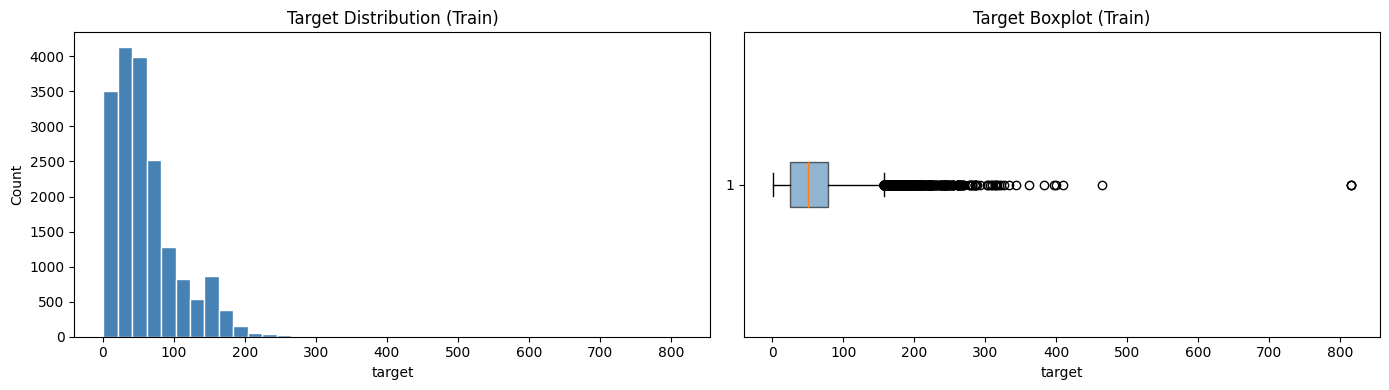

count    18333.000000
mean        61.009191
std         47.123703
min          1.000000
25%         25.000000
50%         50.000000
75%         78.000000
max        815.000000
Name: target, dtype: float64


In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Histogram
axes[0].hist(y_train, bins=40, edgecolor='white', color='steelblue')
axes[0].set_title('Target Distribution (Train)')
axes[0].set_xlabel('target')
axes[0].set_ylabel('Count')

# Boxplot
axes[1].boxplot(y_train, vert=False, patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.6))
axes[1].set_title('Target Boxplot (Train)')
axes[1].set_xlabel('target')

plt.tight_layout()
plt.show()

print(y_train.describe())


---
## 5. ⚙️ Preprocessing Pipeline

A shared `preprocessing_pipeline` is defined once and reused by every model.
It encapsulates all feature engineering so that **no step is ever fitted on val or test data**.

| Step | Transformer | Purpose |
|---|---|---|
| A | `drop_features` | Remove leaky/irrelevant columns (CH₄, target stats, composite ID) |
| B | `GroupedMedianImputer` | Impute NaNs using per-station median - fitted on `X_train` only |
| C | `relative_mean_angles` | Collapse ~32 redundant angle columns → 2 relative features |
| D | `calculate_air_mass_factors` | Compute AMF ratios for NO₂, SO₂, HCHO |
| E | `calculate_atmospheric_indices` | NO₂ tropospheric ratio & cloud pressure thickness |
| F | `cloud_fraction_reduction` | Average per-band cloud fractions → single mean feature |
| G | `sensor_altitude_reduction` | Average per-band sensor altitudes → single mean feature |
| H | Drop metadata | Remove `Date` and `Place_ID` - not valid model inputs |
| I | `RobustScaler` | Scale features using median/IQR - fitted on `X_train` only |

> Steps B and I (the only *fitted* steps) learn their parameters from `X_train` exclusively,
> then apply them unchanged to `X_val` and `X_test`.

In [ ]:
cols_to_drop = ["Place_ID X ", "target_", "ch4"]

preprocessing_pipeline = Pipeline([
    # A. Drop leaky and irrelevant columns by keyword
    ('drop_keywords', FunctionTransformer(lambda x: drop_features(x.copy(), cols_to_drop))),

    # B. Impute missing values using per-station median (Place_ID must still exist here)
    ('imputer', GroupedMedianImputer()),

    # C. Consolidate redundant per-band angle columns into relative_azimuth & relative_zenith
    ('angles',    FunctionTransformer(lambda x: relative_mean_angles(x.copy()))),

    # D. Compute Air Mass Factor ratios for NO2, SO2, HCHO
    ('amf',       FunctionTransformer(lambda x: calculate_air_mass_factors(x.copy()))),

    # E. Compute NO2 tropospheric ratio and cloud pressure thickness
    ('indices',   FunctionTransformer(lambda x: calculate_atmospheric_indices(x.copy()))),

    # F. Reduce cloud fraction collinearity → single mean column
    ('cloud_red', FunctionTransformer(lambda x: cloud_fraction_reduction(x.copy()))),

    # G. Reduce sensor altitude collinearity → single mean column
    ('alt_red',   FunctionTransformer(lambda x: sensor_altitude_reduction(x.copy()))),

    # H. Drop identifier columns - not valid model inputs
    ('drop_meta', FunctionTransformer(lambda x: x.drop(columns=['Date', 'Place_ID'], errors='ignore'))),

    # I. Scale features using median/IQR (robust to outliers)
    ('scaler', RobustScaler())
])

print("Preprocessing pipeline defined with", len(preprocessing_pipeline.steps), "steps.")


Preprocessing pipeline defined with 9 steps.


---
## 6. 📏 Baseline Model - K-Nearest Neighbours

**KNN (k=5)** serves as a simple non-parametric baseline before moving to more complex models.
It makes no assumptions about data distribution and gives a meaningful lower-bound benchmark.

> If a sophisticated model cannot beat KNN, it is a strong signal that something is wrong with the features, split, or training setup.

In [13]:
knn_pipeline = Pipeline([
    ('preprocessor', preprocessing_pipeline),
    ('regressor',    KNeighborsRegressor(n_neighbors=5))
])
knn_pipeline.set_output(transform="pandas")

# Fit on training data only
knn_pipeline.fit(X_train, y_train)

# Predict on all splits
y_pred_train_knn = knn_pipeline.predict(X_train)
y_pred_val_knn   = knn_pipeline.predict(X_val)
y_pred_test_knn  = knn_pipeline.predict(X_test)

print("--- KNN Baseline Results ---")
print(f"{'Split':<12} {'RMSE':>8} {'MAE':>8} {'R²':>8}")
print("-" * 40)
for split, y_true, y_pred in [
    ("Train",      y_train, y_pred_train_knn),
    ("Validation", y_val,   y_pred_val_knn),
    ("Test",       y_test,  y_pred_test_knn),
]:
    rmse = round(root_mean_squared_error(y_true, y_pred), 3)
    mae  = round(mean_absolute_error(y_true, y_pred), 3)
    r2   = round(r2_score(y_true, y_pred), 3)
    print(f"{split:<12} {rmse:>8} {mae:>8} {r2:>8}")


--- KNN Baseline Results ---
Split            RMSE      MAE       R²
----------------------------------------
Train          27.518   18.391    0.659
Validation     32.792    22.68    0.492
Test             33.7   22.554    0.484


---
## 7. 🚀 Advanced Models

### 7.1 XGBoost - Hyperparameter Search Configuration

We use `RandomizedSearchCV` (15 iterations, 3-fold CV) to efficiently explore the XGBoost hyperparameter space.
Scoring uses `neg_root_mean_squared_error` to directly optimise for the competition metric.

> Cross-validation inside `RandomizedSearchCV` runs entirely within `X_train` - the val set remains unseen.

In [14]:
xgb_random_grid = {
    'n_estimators':    randint(10, 100),
    'learning_rate':   uniform(0.01, 0.07),
    'subsample':       uniform(0.7, 0.2),     # Range: 0.7 – 0.9
    'colsample_bytree': uniform(0.7, 0.2),
    'gamma':           [0, 1, 5],
    'reg_lambda':      [1, 10]
}

xgb_base = XGBRegressor(random_state=RSEED, n_jobs=-1, tree_method='hist')

xgb_tuned = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=xgb_random_grid,
    n_iter=15,
    cv=3,
    verbose=1,
    random_state=RSEED,
    scoring='neg_root_mean_squared_error'
)

print("XGBoost search space defined. Will run", 15 * 3, "fits total (15 iters × 3-fold CV).")


XGBoost search space defined. Will run 45 fits total (15 iters × 3-fold CV).


### 7.2 Stacking Regressor - Architecture

The stacking ensemble uses two base learners and one meta-learner:

| Role | Model | Notes |
|---|---|---|
| Base learner 1 | `RandomForestRegressor` | 100 trees, captures non-linear interactions |
| Base learner 2 | `KNeighborsRegressor` | Distance-based, complements tree models |
| Meta-learner | `PolynomialFeatures(3) + LinearRegression` | Learns optimal blend of base predictions |

Base learners are cross-validated (5-fold) within `X_train` so the meta-learner trains on out-of-fold predictions only.

In [15]:
# Base learner: KNN (inside a pipeline for compatibility)
knn_pipe = Pipeline([
    ('knn', KNeighborsRegressor())
])

# Base learner: Random Forest
rf_model = RandomForestRegressor(n_estimators=100, random_state=RSEED, n_jobs=-1)

# Meta-learner: Polynomial (degree 3) Linear Regression
poly_pipe = Pipeline([
    ('poly',    PolynomialFeatures(degree=3)),
    ('lin_reg', LinearRegression())
])

stacking_model = StackingRegressor(
    estimators=[
        ('rf',  rf_model),
        ('knn', knn_pipe)
    ],
    final_estimator=poly_pipe,
    cv=5
)

print("Stacking model defined: RF + KNN → Polynomial Linear Regression meta-learner.")


Stacking model defined: RF + KNN → Polynomial Linear Regression meta-learner.


---
## 8. 📊 Model Comparison

All models are evaluated through the same shared preprocessing pipeline.
Results are collected across Train, Validation, and Test splits.

> The test set is used here for final reporting only - it was never seen during fitting or tuning.

In [16]:
models = {
    "KNN":      KNeighborsRegressor(n_neighbors=5),
    "XGBoost":  xgb_tuned,
    "Stacking": stacking_model,
}

results = {}  # Store results for summary table

for name, model in models.items():
    print(f"\n{'='*50}")
    print(f"  Running: {name}")
    print(f"{'='*50}")

    # Attach the shared preprocessing pipeline to this model
    full_pipeline = Pipeline([
        ('preprocessor', preprocessing_pipeline),
        ('regressor',    model)
    ])
    full_pipeline.set_output(transform="pandas")

    # Fit on training data only
    full_pipeline.fit(X_train, y_train)

    # Predict on all three splits
    y_pred_train = full_pipeline.predict(X_train)
    y_pred_val   = full_pipeline.predict(X_val)
    y_pred_test  = full_pipeline.predict(X_test)

    # Compute metrics
    results[name] = {}
    print(f"\n  {'Split':<12} {'RMSE':>8} {'MAE':>8} {'R²':>8}")
    print(f"  {'-'*40}")
    for split, y_true, y_pred in [
        ("Train",      y_train, y_pred_train),
        ("Validation", y_val,   y_pred_val),
        ("Test",       y_test,  y_pred_test),
    ]:
        rmse = round(root_mean_squared_error(y_true, y_pred), 3)
        mae  = round(mean_absolute_error(y_true, y_pred), 3)
        r2   = round(r2_score(y_true, y_pred), 3)
        results[name][split] = {'RMSE': rmse, 'MAE': mae, 'R2': r2}
        print(f"  {split:<12} {rmse:>8} {mae:>8} {r2:>8}")



  Running: KNN

  Split            RMSE      MAE       R²
  ----------------------------------------
  Train          27.518   18.391    0.659
  Validation     32.792    22.68    0.492
  Test             33.7   22.554    0.484

  Running: XGBoost
Fitting 3 folds for each of 15 candidates, totalling 45 fits

  Split            RMSE      MAE       R²
  ----------------------------------------
  Train          26.536   17.967    0.683
  Validation     29.252    20.48    0.596
  Test           30.493   20.484    0.577

  Running: Stacking

  Split            RMSE      MAE       R²
  ----------------------------------------
  Train          23.677    8.114    0.748
  Validation     28.028   19.238    0.629
  Test           29.306   19.262     0.61


### 8.1 Summary Table - Validation & Test Performance

Print a consolidated comparison across all models to guide final model selection.

In [17]:
print(f"\n{'='*60}")
print(f"  MODEL COMPARISON SUMMARY")
print(f"{'='*60}")
print(f"  {'Model':<12} {'Val RMSE':>10} {'Val R²':>8} {'Test RMSE':>10} {'Test R²':>8}")
print(f"  {'-'*52}")
for name, splits in results.items():
    v = splits.get('Validation', {})
    t = splits.get('Test', {})
    print(f"  {name:<12} {v.get('RMSE',''):>10} {v.get('R2',''):>8} {t.get('RMSE',''):>10} {t.get('R2',''):>8}")



  MODEL COMPARISON SUMMARY
  Model          Val RMSE   Val R²  Test RMSE  Test R²
  ----------------------------------------------------
  KNN              32.792    0.492       33.7    0.484
  XGBoost          29.252    0.596     30.493    0.577
  Stacking         28.028    0.629     29.306     0.61


---
## 8.2 📈 Result Visualisations

All three plots call functions defined in `function.py` (Section 6 - Result Plots).
The `results` dictionary is populated by the model comparison loop in Section 8.1.


### Plot 1 - Model Comparison: RMSE & R²

Grouped bar chart comparing all models across Train, Validation, and Test splits.
Built directly from the `results` dict - no hardcoded values needed.


Saved: ../Images/model_comparison.png


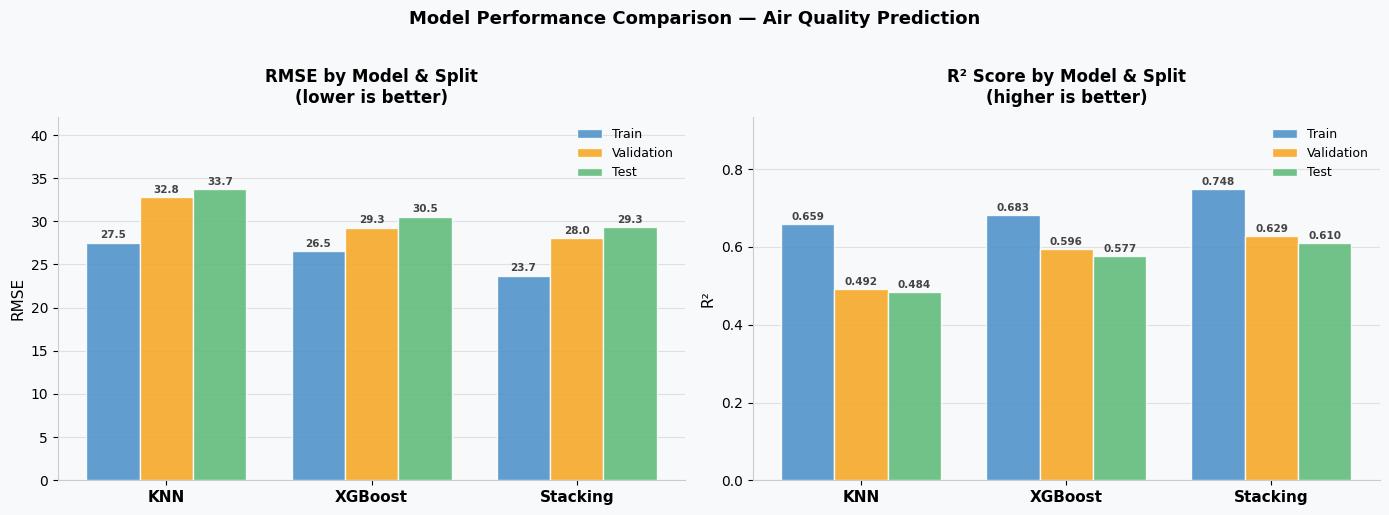

In [22]:
import os
os.makedirs('../Images', exist_ok=True)

plot_model_comparison(results, save_path='../Images/model_comparison.png')


### Plot 2 - Actual vs Predicted (Best Model: Stacking, Test Set)

Points along the diagonal represent perfect predictions.
Scatter around it shows the model's uncertainty across the target range.


Saved: ../Images/actual_vs_predicted.png


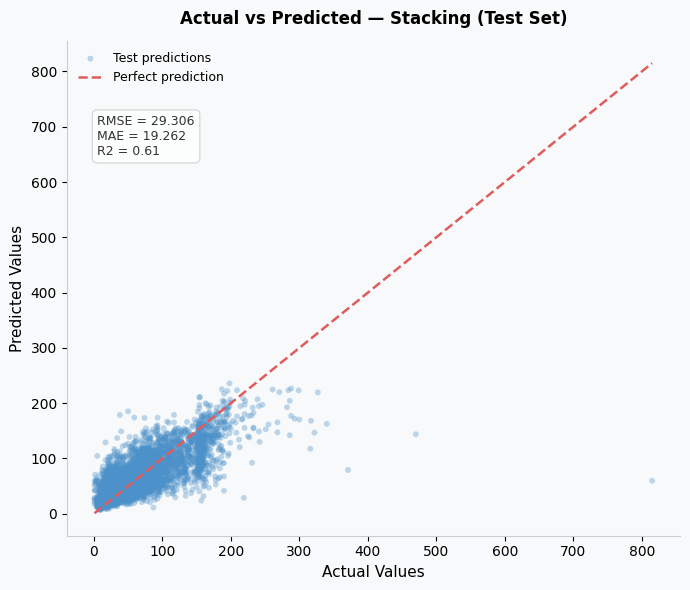

In [23]:
# Fit Stacking pipeline and generate test predictions
stacking_pipeline = Pipeline([
    ('preprocessor', preprocessing_pipeline),
    ('regressor',    stacking_model)
])
stacking_pipeline.set_output(transform='pandas')
stacking_pipeline.fit(X_train, y_train)
y_pred_stacking_test = stacking_pipeline.predict(X_test)

plot_actual_vs_predicted(
    y_true=y_test,
    y_pred=y_pred_stacking_test,
    model_name='Stacking',
    metrics={'RMSE': 29.306, 'MAE': 19.262, 'R2': 0.610},
    save_path='../Images/actual_vs_predicted.png'
)


### Plot 3 - Residual Plot (Best Model: Stacking, Test Set)

**Left:** Residuals vs Predicted - a random scatter around zero means no systematic bias.
**Right:** Residual histogram - should be roughly normal and centred near zero.


Saved: ../Images/residuals.png


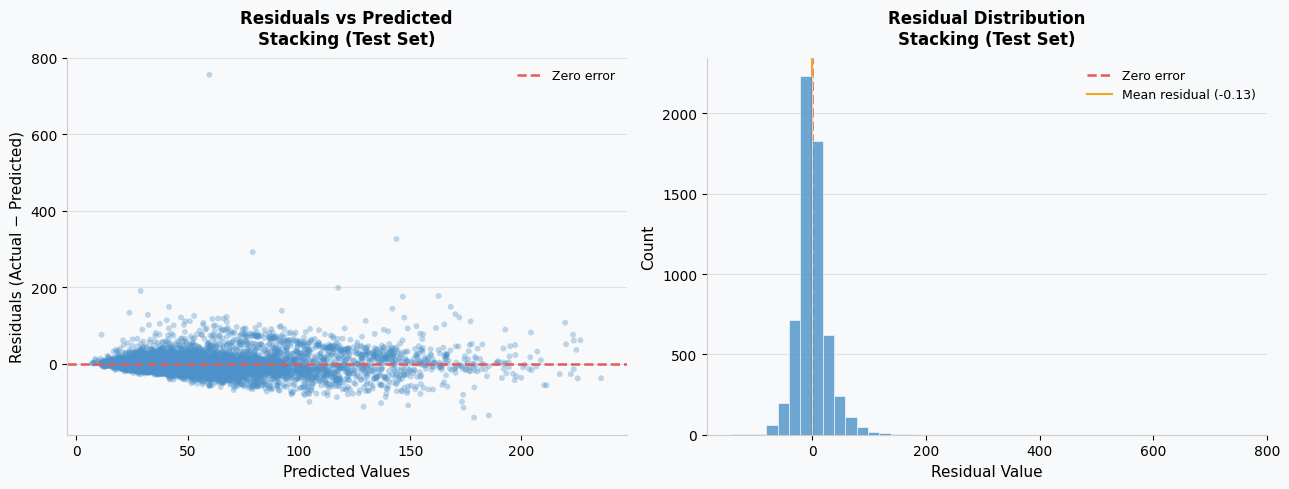

In [24]:
plot_residuals(
    y_true=y_test,
    y_pred=y_pred_stacking_test,
    model_name='Stacking',
    save_path='../Images/residuals.png'
)
